<a href="https://colab.research.google.com/github/Ponnarasi-p/Public_Transport_Passenger-Kovai.co-/blob/main/Copy_of_Kovai_co.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv("/content/Daily_Public_Transport_Passenger_Journeys_by_Service_Type_20250603.csv")

In [ ]:
df.head()

,Date,Local Route,Light Rail,Peak Service,Rapid Route,School,Other
0,30/08/2024,16436,10705,225,19026,3925,59.0
1,15/09/2023,15499,10671,267,18421,4519,61.0
2,28/12/2021,1756,2352,0,3775,0,13.0
3,11/01/2023,10536,8347,223,14072,0,48.0
4,11/09/2021,820,612,0,1283,0,11.0


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [ ]:
df.head()

,Date,Local Route,Light Rail,Peak Service,Rapid Route,School,Other
0,2024-08-30,16436,10705,225,19026,3925,59.0
1,2023-09-15,15499,10671,267,18421,4519,61.0
2,2021-12-28,1756,2352,0,3775,0,13.0
3,2023-01-11,10536,8347,223,14072,0,48.0
4,2021-09-11,820,612,0,1283,0,11.0


In [ ]:
#check for null values
df.isnull().sum()

,0
Date,0
Local Route,0
Light Rail,0
Peak Service,0
Rapid Route,0
School,0
Other,20


"Other" column alone have 20 missing values.

In [ ]:
df.describe()

,Date,Local Route,Light Rail,Peak Service,Rapid Route,School,Other
count,1918,1918.000000,1918.000000,1918.000000,1918.000000,1918.000000,1898.000000
mean,2022-02-13 12:00:00,9891.395203,7195.446298,179.581335,12597.213243,2352.694995,43.390411
min,2019-07-01 00:00:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020-10-22 06:00:00,3044.500000,4463.500000,0.000000,6383.000000,0.000000,14.000000
50%,2022-02-13 12:00:00,11417.000000,7507.000000,193.000000,13106.500000,567.500000,40.000000
75%,2023-06-07 18:00:00,15517.500000,10008.250000,313.750000,17924.750000,4914.000000,68.000000
max,2024-09-29 00:00:00,21070.000000,15154.000000,1029.000000,28678.000000,7255.000000,1105.000000
std,NaN,6120.715714,3345.616428,156.532738,6720.494557,2494.766306,41.746882


In [ ]:
df['Other'].fillna(df['Other'].mean(), inplace=True)

/tmp/ipython-input-3000724742.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Other'].fillna(df['Other'].mean(), inplace=True)


Replaced those missing values with the mean value.

In [ ]:
df = df.sort_values('Date')
df.head()

,Date,Local Route,Light Rail,Peak Service,Rapid Route,School,Other
1013,2019-07-01,15987,9962,407,21223,3715,43.390411
1120,2019-07-02,16895,10656,409,21715,3993,43.390411
1451,2019-07-03,16613,10658,427,22025,3638,43.390411
1171,2019-07-04,16604,10445,437,21868,3576,43.390411
1523,2019-07-05,16040,10532,400,20697,2856,43.390411


In [ ]:
df['Total_Passengers'] = df[['Local Route','Light Rail','Peak Service','Rapid Route','School','Other']].sum(axis=1)
df.head()

,Date,Local Route,Light Rail,Peak Service,Rapid Route,School,Other,Total_Passengers
1013,2019-07-01,15987,9962,407,21223,3715,43.390411,51337.390411
1120,2019-07-02,16895,10656,409,21715,3993,43.390411,53711.390411
1451,2019-07-03,16613,10658,427,22025,3638,43.390411,53404.390411
1171,2019-07-04,16604,10445,437,21868,3576,43.390411,52973.390411
1523,2019-07-05,16040,10532,400,20697,2856,43.390411,50568.390411


Created a new key column — Total_Passengers, which will be used for trend analysis and forecasting.


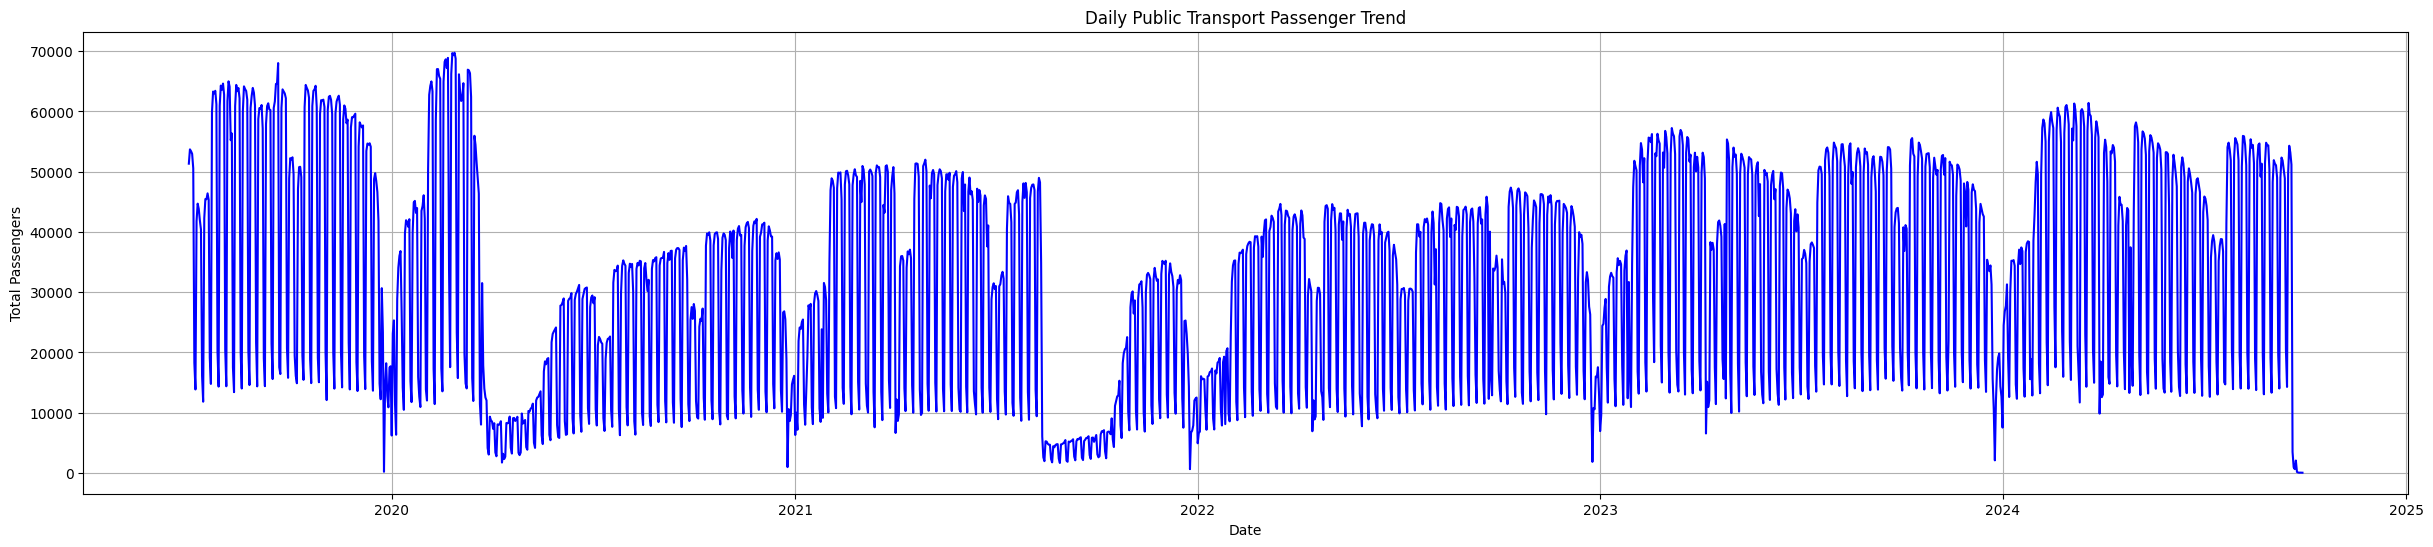

In [ ]:
plt.figure(figsize=(30,6))
plt.plot(df['Date'], df['Total_Passengers'], color='blue')
plt.title("Daily Public Transport Passenger Trend")
plt.xlabel("Date")
plt.ylabel("Total Passengers")
plt.grid(True)
plt.show()

It seems to have some trend in the data.Total passenger numbers increasing over time.Noticeable dips likely weekends, holidays, or lockdown periods

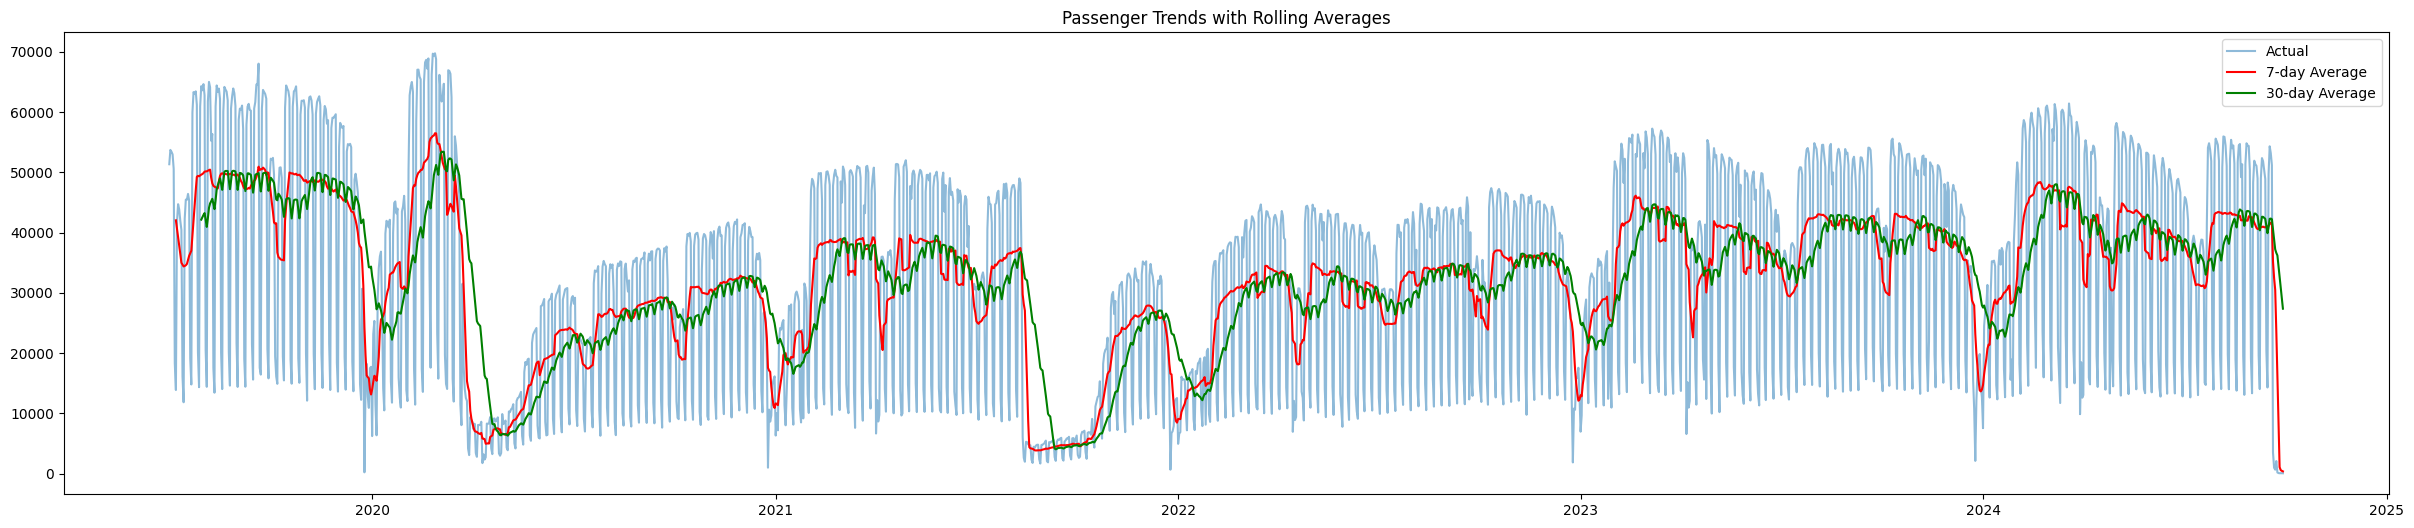

In [ ]:
df['Rolling_7'] = df['Total_Passengers'].rolling(7).mean()
df['Rolling_30'] = df['Total_Passengers'].rolling(30).mean()
plt.figure(figsize=(30,6))
plt.plot(df['Date'], df['Total_Passengers'], label='Actual', alpha=0.5)
plt.plot(df['Date'], df['Rolling_7'], label='7-day Average', color='red')
plt.plot(df['Date'], df['Rolling_30'], label='30-day Average', color='green')
plt.legend()
plt.title("Passenger Trends with Rolling Averages")
plt.show()


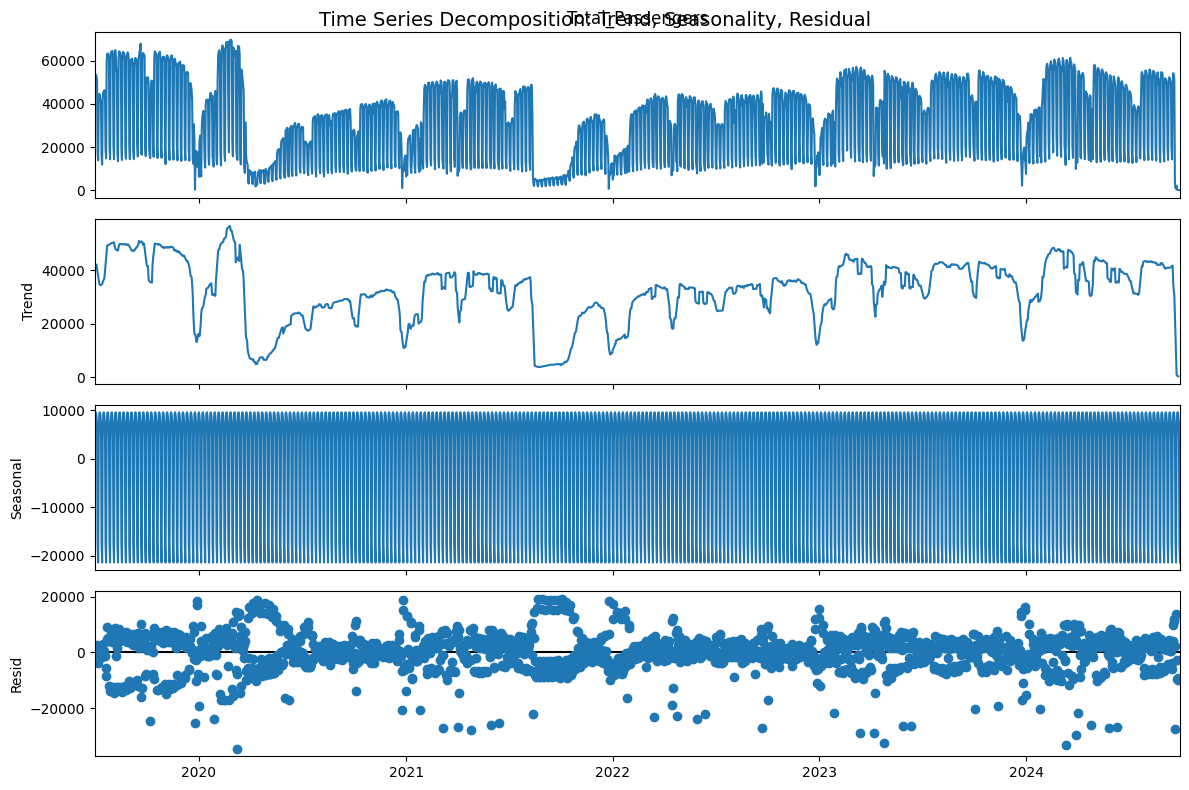

In [ ]:

from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Setting Date as index (required for decomposition)
df.set_index('Date', inplace=True)

# Applying seasonal decomposition
decomposition = seasonal_decompose(df['Total_Passengers'], model='additive', period=7)  # 7 for weekly pattern

# Plot the decomposition
plt.rcParams.update({'figure.figsize': (12,8)})
decomposition.plot()
plt.suptitle("Time Series Decomposition: Trend, Seasonality, Residual", fontsize=14)
plt.show()


The Augmented Dickey-Fuller (ADF) Test checks whether our data is stationary (no trend/seasonality).
Most time-series forecasting models (like ARIMA) need stationary data. Prophet can handle non-stationary data.

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Run ADF test
result = adfuller(df['Total_Passengers'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"\t{key}: {value}")

if result[1] < 0.05:
    print("\n The series is stationary (no significant trend/seasonality).")
else:
    print("\n The series is NOT stationary (has trend or seasonality).")


ADF Statistic: -4.30700295883744
p-value: 0.000431970663566355
Critical Values:
	1%: -3.4338036790464495
	5%: -2.8630656035129878
	10%: -2.5675821738080615

 The series is stationary (no significant trend/seasonality).


The test statistics should be less than the critical values.The p-value is less than 0.5.

The ADF test confirmed the data is stationary — suitable for ARIMA modeling.


p-value = 0.00043 (Stationary).So no differencing is needed.Hence,d = 0.We use two diagnostic plots to determine p and q:
ACF (Autocorrelation Function) - helps choose q
PACF (Partial Autocorrelation Function) -helps choose p


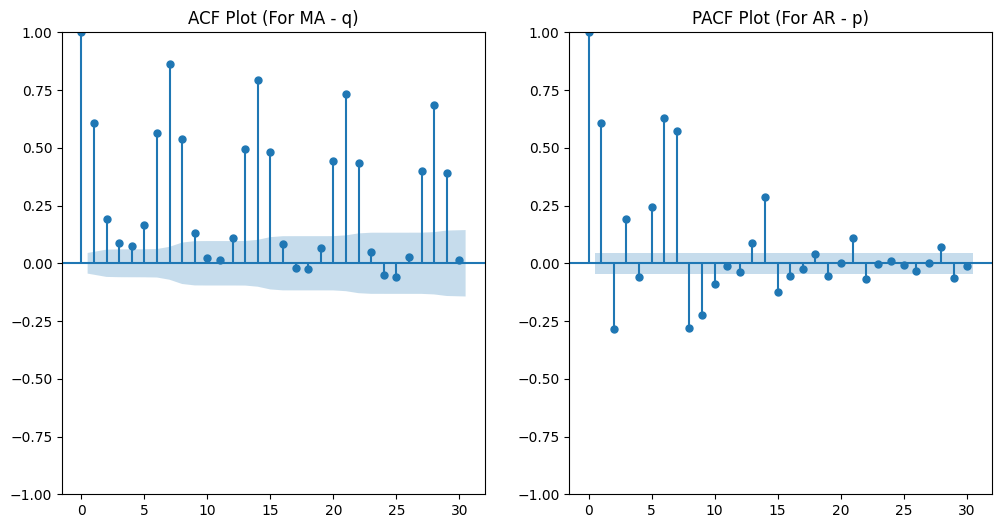

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plot_acf(df['Total_Passengers'], ax=plt.gca(), lags=30)
plt.title("ACF Plot (For MA - q)")

plt.subplot(1,2,2)
plot_pacf(df['Total_Passengers'], ax=plt.gca(), lags=30)
plt.title("PACF Plot (For AR - p)")

plt.show()


both cut off around lag 2.so,
(p, d, q) = (2, 0, 2)

In [ ]:
for p in range(0, 3):
    for q in range(0, 3):
        try:
            model = ARIMA(df['Total_Passengers'], order=(p, 0, q))
            results = model.fit()
            print(f"ARIMA({p},0,{q}) -> AIC: {results.aic}")
        except:
            continue


ARIMA(0,0,0) -> AIC: 55644.23618660821
ARIMA(0,0,1) -> AIC: 42027.22372506695
ARIMA(0,0,2) -> AIC: 41935.43986849708
ARIMA(1,0,0) -> AIC: 42175.043433788
ARIMA(1,0,1) -> AIC: 41936.18774187355
ARIMA(1,0,2) -> AIC: 41937.43911696387
ARIMA(2,0,0) -> AIC: 42014.88157920781
ARIMA(2,0,1) -> AIC: 41938.102625565414
ARIMA(2,0,2) -> AIC: 41940.6154897252


ARIMA(0,0,2) has lowest value.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# TO Ensure 'Date' column is datetime and sorted
df = df.reset_index()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)


In [ ]:
#ARIMA model
model = ARIMA(df['Total_Passengers'], order=(0,0,2))
results = model.fit()

print(results.summary())


                               SARIMAX Results                                
Dep. Variable:       Total_Passengers   No. Observations:                 1918
Model:                 ARIMA(0, 0, 2)   Log Likelihood              -20963.720
Date:                Tue, 04 Nov 2025   AIC                          41935.440
Time:                        04:55:17   BIC                          41957.676
Sample:                    07-01-2019   HQIC                         41943.622
                         - 09-29-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.226e+04    685.731     47.044      0.000    3.09e+04    3.36e+04
ma.L1          0.8590      0.036     23.940      0.000       0.789       0.929
ma.L2          0.2564      0.032      8.128      0.0

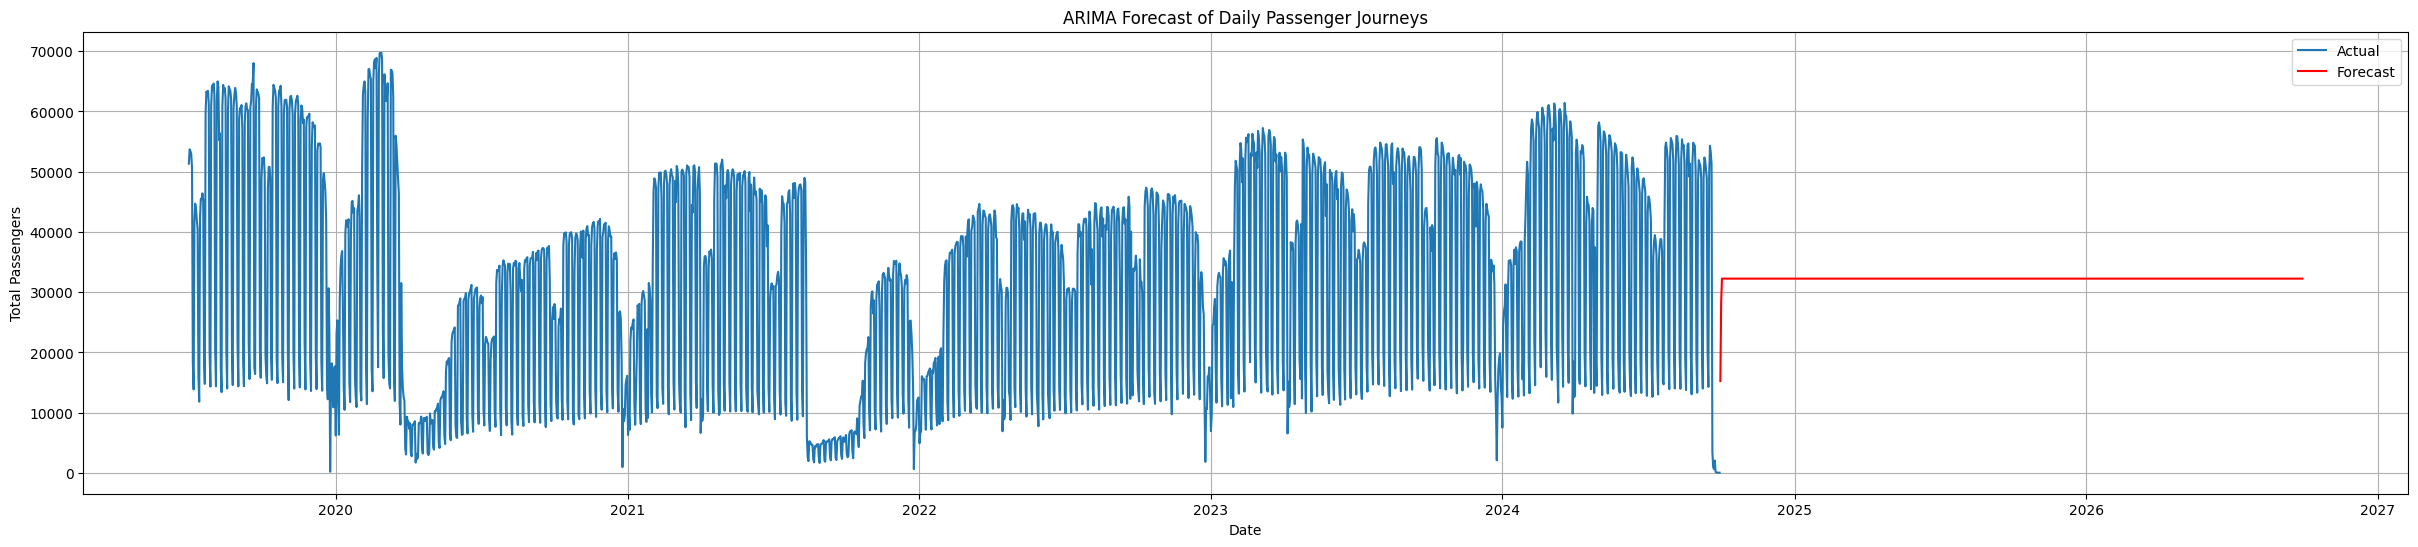

In [ ]:
forecast_steps = 730
forecast = results.forecast(steps=forecast_steps)

# Create forecast dates
forecast_dates = pd.date_range(df.index[-1], periods=forecast_steps + 1, freq='D')[1:]


plt.figure(figsize=(30,6))
plt.plot(df['Total_Passengers'], label='Actual')
plt.plot(forecast_dates, forecast, label='Forecast', color='red')
plt.title("ARIMA Forecast of Daily Passenger Journeys")
plt.xlabel("Date")
plt.ylabel("Total Passengers")
plt.legend()
plt.grid(True)
plt.show()


Mean Absolute Error (MAE): 17023.362540472175
Root Mean Squared Error (RMSE): 18355.088557048868


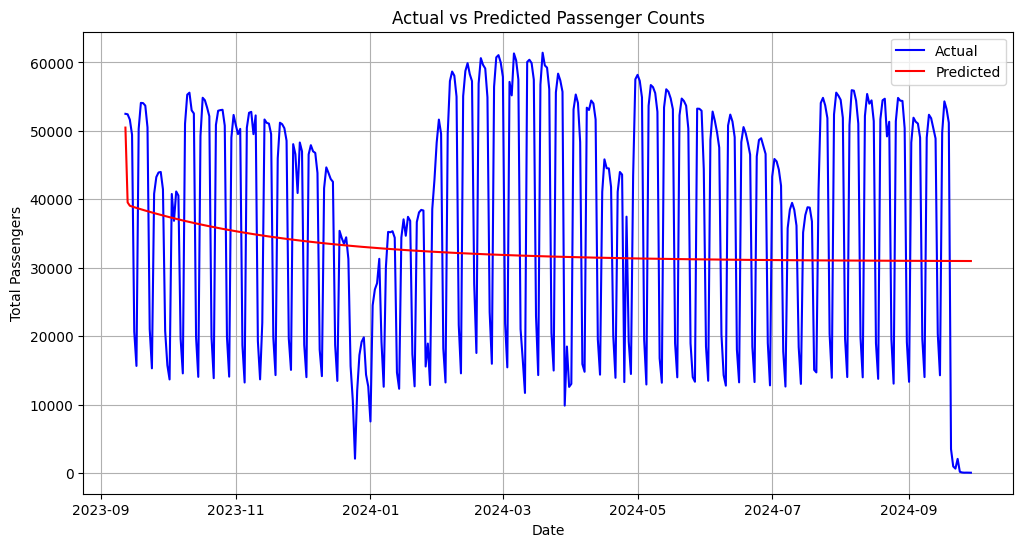

In [ ]:
train_size = int(len(df) * 0.8)
train, test = df['Total_Passengers'][:train_size], df['Total_Passengers'][train_size:]

model_eval = ARIMA(train, order=(2,0,2))
result_eval = model_eval.fit()
forecast_eval = result_eval.forecast(steps=len(test))

# Evaluation metrics
mae = mean_absolute_error(test, forecast_eval)
rmse = np.sqrt(mean_squared_error(test, forecast_eval))

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)

# Plot comparison
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual', color='blue')
plt.plot(test.index, forecast_eval, label='Predicted', color='red')
plt.title("Actual vs Predicted Passenger Counts")
plt.xlabel("Date")
plt.ylabel("Total Passengers")
plt.legend()
plt.grid(True)
plt.show()


Still has some Errors.We will try doing with SARIMA modoel as it works well for Seasonality.

In [ ]:
# Try nearby models
for order in [(0,0,1), (1,0,1), (1,0,2), (2,0,2)]:
    model = ARIMA(df['Total_Passengers'], order=order)
    results = model.fit()
    print(f"ARIMA{order} -> AIC: {results.aic}")


ARIMA(0, 0, 1) -> AIC: 42027.22372506695
ARIMA(1, 0, 1) -> AIC: 41936.18774187355
ARIMA(1, 0, 2) -> AIC: 41937.43911696387
ARIMA(2, 0, 2) -> AIC: 41940.6154897252


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df['Total_Passengers'], order=(0,0,2), seasonal_order=(1,1,1,7))  # 7 = weekly seasonality
results = model.fit()
print(results.summary())


                                      SARIMAX Results                                      
Dep. Variable:                    Total_Passengers   No. Observations:                 1918
Model:             SARIMAX(0, 0, 2)x(1, 1, [1], 7)   Log Likelihood              -19863.227
Date:                             Tue, 04 Nov 2025   AIC                          39736.453
Time:                                     05:01:45   BIC                          39764.230
Sample:                                 07-01-2019   HQIC                         39746.676
                                      - 09-29-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4435      0.018     24.278      0.000       0.408       0.479
ma.L2          0.1993      

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Assuming your df already has 'Date' as index and 'Total_Passengers' column
df = df.asfreq('D')  # Ensure daily frequency

# Fill missing values if any
df['Total_Passengers'].fillna(method='ffill', inplace=True)


In [ ]:
train = df.iloc[:-30]
test = df.iloc[-30:]


In [ ]:
model = SARIMAX(train['Total_Passengers'],
                order=(2,0,2),
                seasonal_order=(1,1,1,7))   # weekly pattern
results = model.fit(disp=False)


In [ ]:
pred = results.get_forecast(steps=30)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int()


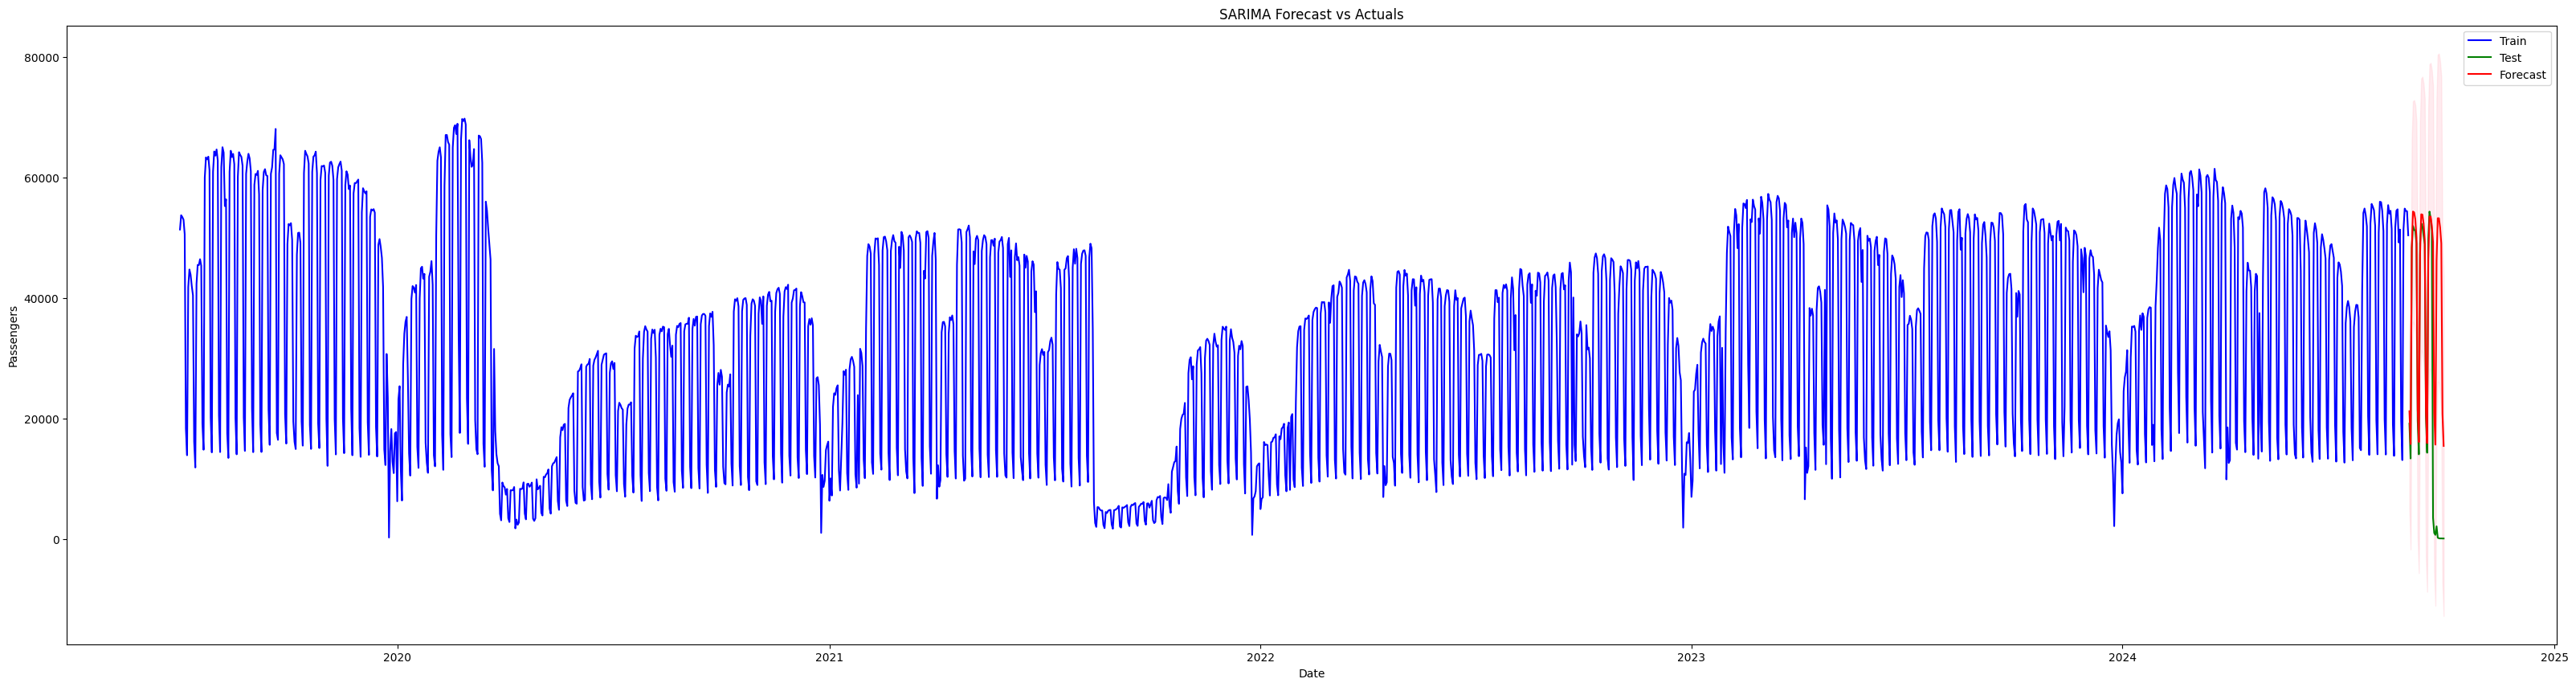

In [ ]:
plt.figure(figsize=(40,10))
plt.plot(train.index, train['Total_Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Total_Passengers'], label='Test', color='green')
plt.plot(pred_mean.index, pred_mean, label='Forecast', color='red')
plt.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], color='pink', alpha=0.3)
plt.title("SARIMA Forecast vs Actuals")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test['Total_Passengers'], pred_mean)
rmse = np.sqrt(mean_squared_error(test['Total_Passengers'], pred_mean))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Mean Absolute Error (MAE): 13331.98
Root Mean Squared Error (RMSE): 23163.26


I tested both ARIMA and SARIMA models to forecast daily public transport passenger journeys.
After testing various parameters, ARIMA(2,0,2) gave a baseline MAE of 17,023.
However, when I included weekly seasonality using SARIMA(2,0,2)(1,1,1,7),
the MAE improved to 13,331 — indicating that the dataset has a weekly seasonal trend (likely weekday vs weekend passenger differences).
Hence, SARIMA is the more suitable model for this dataset

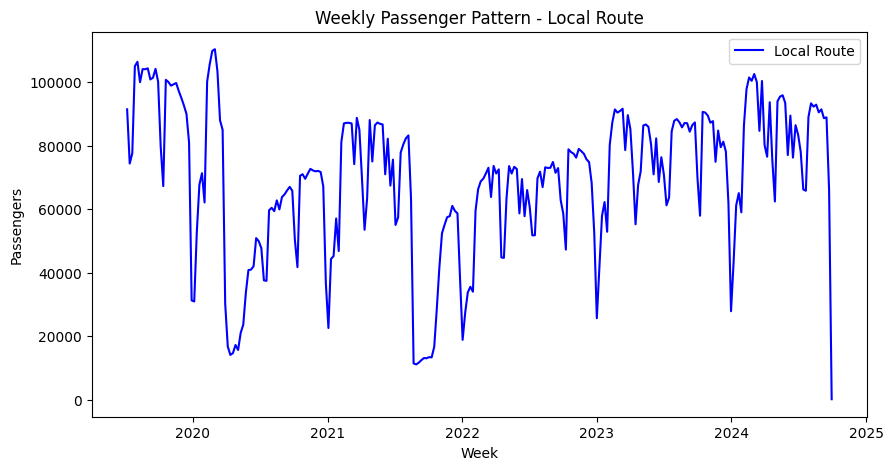

In [ ]:

df = df[['Local Route','Light Rail','Peak Service','Rapid Route','School']]

# WEEKLY SEASONALITY DETECTION
df_weekly = df.resample('W').sum()
plt.figure(figsize=(10,5))
plt.plot(df_weekly['Local Route'], label='Local Route', color='blue')
plt.title("Weekly Passenger Pattern - Local Route")
plt.xlabel("Week")
plt.ylabel("Passengers")
plt.legend()
plt.show()




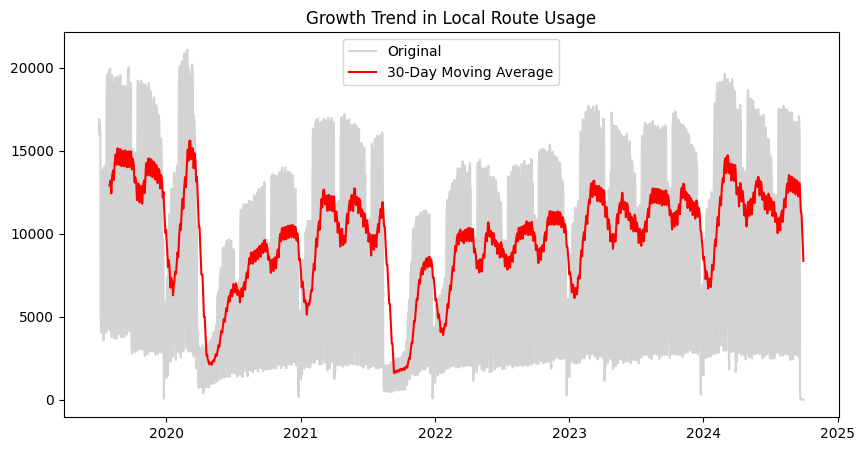

In [ ]:
#  TREND DETECTION (MOVING AVERAGE)
df['LocalRoute_Trend'] = df['Local Route'].rolling(window=30).mean()

plt.figure(figsize=(10,5))
plt.plot(df['Local Route'], color='lightgray', label='Original')
plt.plot(df['LocalRoute_Trend'], color='red', label='30-Day Moving Average')
plt.title("Growth Trend in Local Route Usage")
plt.legend()
plt.show()


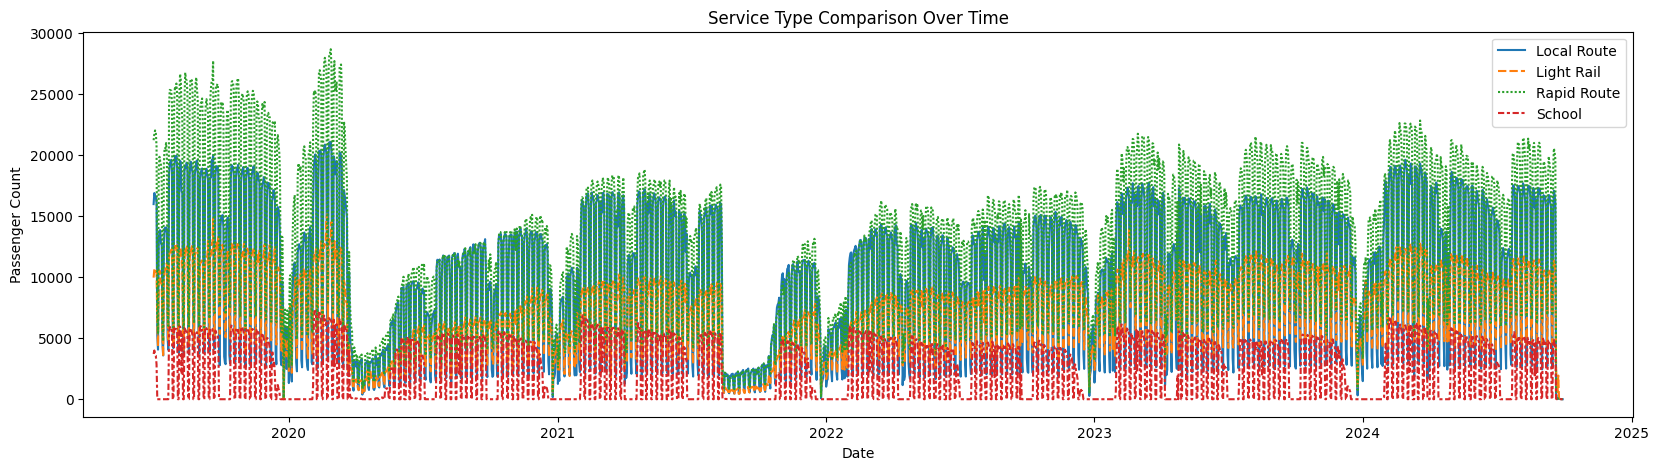

In [ ]:
#  SERVICE TYPE COMPARISON
plt.figure(figsize=(20,5))
sns.lineplot(data=df[['Local Route','Light Rail','Rapid Route','School']])
plt.title("Service Type Comparison Over Time")
plt.ylabel("Passenger Count")
plt.show()


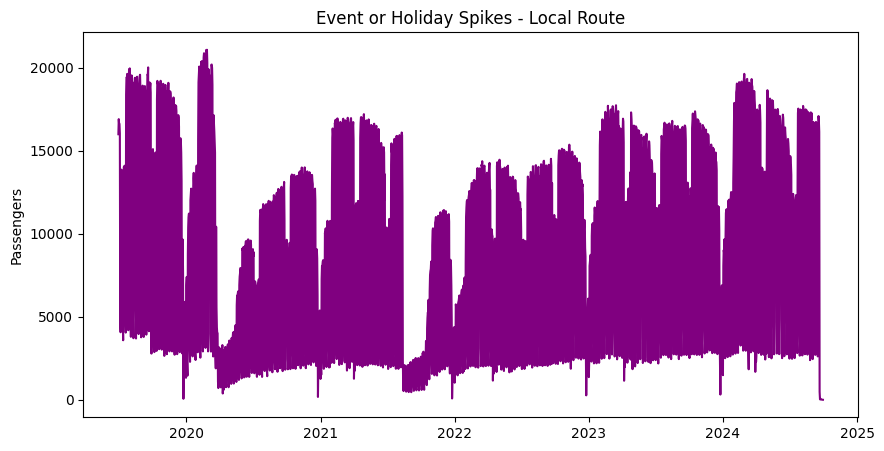

In [ ]:
# DETECT COVID OR EVENT SPIKES
plt.figure(figsize=(10,5))
plt.plot(df['Local Route'], color='purple')
plt.title("Event or Holiday Spikes - Local Route")
plt.ylabel("Passengers")
plt.show()

Sudden dips or spikes in the line may indicate holidays or disruptions.

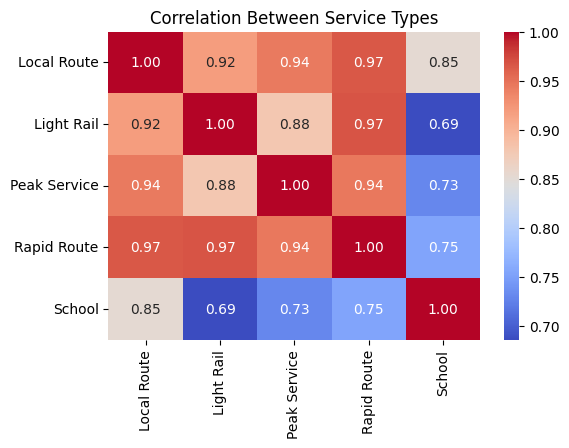

In [ ]:
# CORRELATION BETWEEN SERVICE TYPES
corr_matrix = df[['Local Route','Light Rail','Peak Service','Rapid Route','School']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Service Types")
plt.show()

Task 1:
4to 5 Key Insights:
1.Weekly Seasonality Detected:
   Passenger count shows a clear weekly pattern — peaks on weekdays and dips on weekends.
2.Service Type Comparison:
   - Local Route contributes the highest number of daily passengers.  
   - Light Rail and Rapid Route have steady but lower volumes.  
   - School category peaks only during school months.
  3.COVID/Post-COVID Recovery or Event Spikes:
   The dataset shows occasional dips/spikes, which may be due to external factors like holidays or public events.
   4.Correlation Between Service Types:
   Services like Local Route and Peak Service are positively correlated — when general passengers increase, peak-hour usage also rises.
   5.Growth Trend in Public Transport Usage:
   Overall passenger journeys have a gradual upward trend, indicating increased public transport usage over time.



FORECASTING OF LOCAL ROUTE,LIGHT RAIL,PEAK SERVICE,RAPID ROUTE,SCHOOL FOR THE NEXT 7 DAYS.


🔹 Forecasting for: Local Route


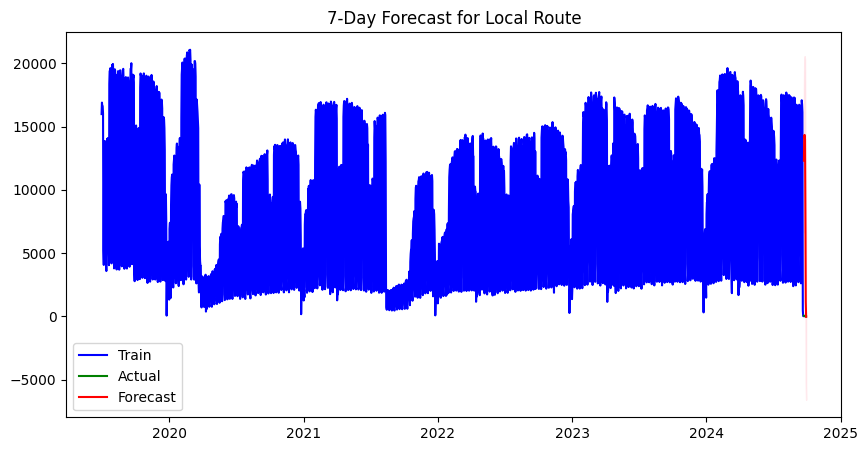


🔹 Forecasting for: Light Rail


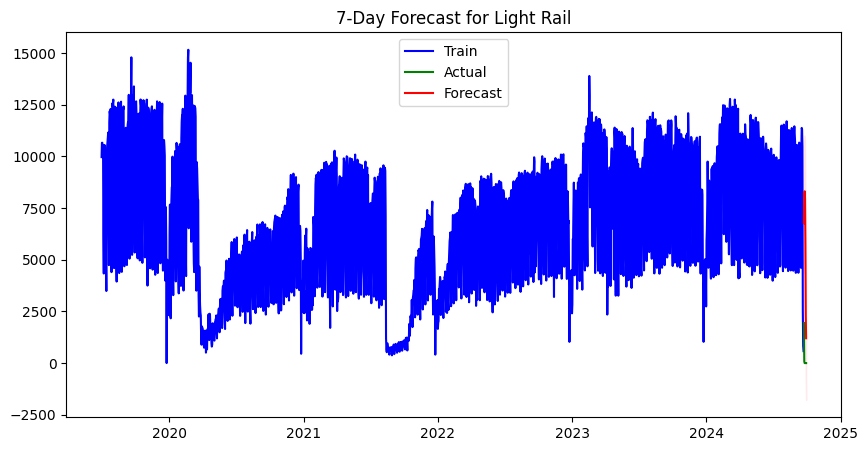


🔹 Forecasting for: Peak Service


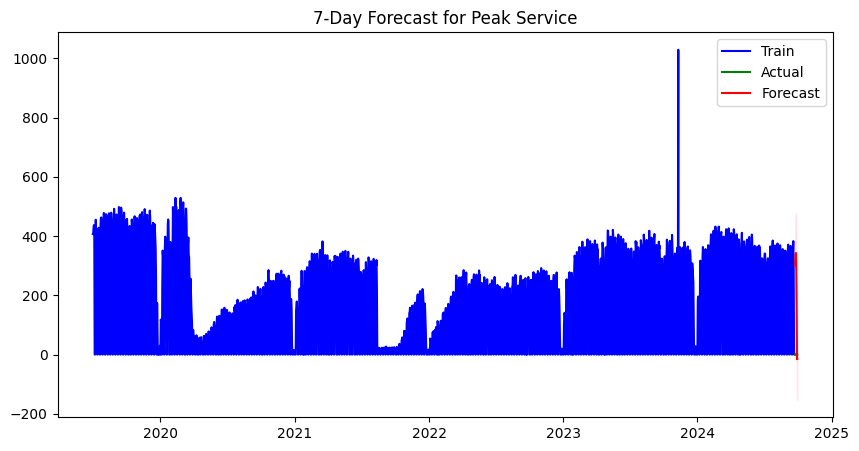


🔹 Forecasting for: Rapid Route


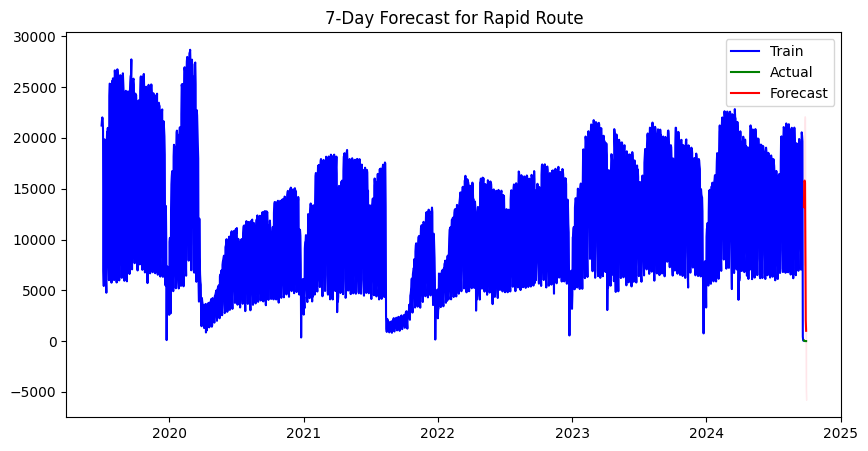


🔹 Forecasting for: School


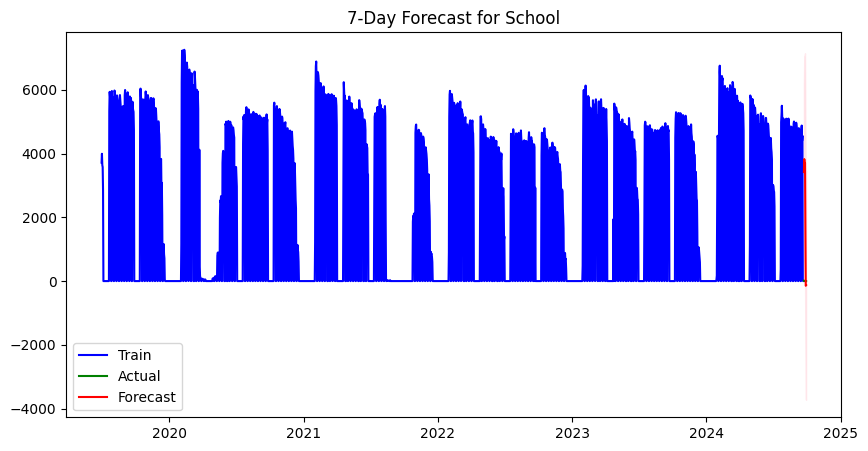

,Local Route,Light Rail,Peak Service,Rapid Route,School
2024-09-23,12301.747764,6766.861993,301.811137,13189.001854,3419.593849
2024-09-24,14317.346026,8149.102570,335.567921,15719.070072,3826.260343
2024-09-25,14341.424511,8309.422259,342.990507,15804.895965,3687.951913
2024-09-26,13980.293223,7964.432005,290.293704,15572.841481,3703.922548
2024-09-27,8225.975321,5851.083301,166.093449,8424.113756,1669.847642
2024-09-28,1170.080079,2351.299708,-15.597748,2064.901380,-147.783771
2024-09-29,-33.126237,1200.875834,-14.777662,1016.037986,-130.226716


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

forecast_results = {}

for column in ['Local Route', 'Light Rail', 'Peak Service', 'Rapid Route', 'School']:
    print(f"\n🔹 Forecasting for: {column}")
    df_column = df[[column]].asfreq('D')
    df_column[column].fillna(method='ffill', inplace=True)

    # Train-Test Split (keep last 7 days for test)
    train = df_column.iloc[:-7]
    test = df_column.iloc[-7:]

    # Fit SARIMA
    model = SARIMAX(train[column],
                    order=(2,0,2),
                    seasonal_order=(1,1,1,7),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    results = model.fit(disp=False)

    # Forecast next 7 days
    forecast = results.get_forecast(steps=7)
    forecast_mean = forecast.predicted_mean
    forecast_ci = forecast.conf_int()

    # Store results
    forecast_results[column] = forecast_mean

    # Plot forecast
    plt.figure(figsize=(10,5))
    plt.plot(train.index, train[column], label='Train', color='blue')
    plt.plot(test.index, test[column], label='Actual', color='green')
    plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='red')
    plt.fill_between(forecast_ci.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='pink', alpha=0.3)
    plt.title(f"7-Day Forecast for {column}")
    plt.legend()
    plt.show()

# Combine all forecast results
forecast_df = pd.DataFrame(forecast_results)
forecast_df
